# Model 3 — Lactate curve reconstruction

This model reconstructs the full lactate curve over time using SmO₂ data.

It combines:
- the predicted lactate peak (Model 2),
- a fixed time to peak,
- and a physiological model describing the rise and decay of lactate.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

# 1) CONFIGURATION
CSV_FILES = {
    "Alexis": "../DATA/Alexis_wingate.csv",
    "Antoine": "../DATA/Antoine_wingate.csv",
    "Jinwei": "../DATA/Jinwei_wingate.csv",
    "Victor": "../DATA/Victor_wingate.csv",
}

XLS_FILE = "../DATA/Physio_Session2_Wingate.xlsx"
SHEET_NAME = "data"

# Manual SmO2 baseline values provided by the user
MANUAL_SMO2_BASELINE = {
    "Alexis": 67.0,
    "Victor": 73.0,
    "Antoine": 70.0,
    "Jinwei": 76.0,
}

# Wingate timing
START_TIME_S = 15
WINGATE_DURATION = 30
END_TIME_S = START_TIME_S + WINGATE_DURATION

# Fixed time to peak lactate
T_PEAK_MIN_FIXED = 3.0
T_PEAK_S_FIXED = END_TIME_S + T_PEAK_MIN_FIXED * 60  # 45 + 180 = 225 s

# Optional fixed lactate baseline
# If you prefer to use measured lactate baseline, set USE_MEASURED_LA_BASELINE = True
USE_MEASURED_LA_BASELINE = True
LA_BASELINE_ASSUMED = 1.5

# Reconstruction parameters
TALAC_S = 2.1
K_RISE = 4
# Dunst-style exercise-phase model parameters (calibrated to the same end-of-exercise handoff)
EXERCISE_K3 = 0.18
EXERCISE_K4 = 0.06
EXERCISE_DELAY_S = 2.0

# Recovery kinetics parameters for Durand et al. (2021) rewrite of Freund model
GAMMA1_RECOVERY = 1 / 300
GAMMA2_RECOVERY = 1 / 2000

SLOPE_WINDOW = 10



## Model

The reconstruction is done in three steps:

1. The lactate increase during exercise is modeled with a Dunst-style sprint equation.
2. The value at end of exercise is taken from that exercise-phase model and becomes the onset of recovery.
3. The full lactate curve is then completed with the Durand/Freund recovery equation.

The exercise-phase model is only applied from 2 seconds after exercise onset until the end of the Wingate test. Before that delay, lactate is kept at baseline.

This keeps the exercise and recovery phases separated at the physiologically meaningful transition point: the end of exercise.

In [48]:
# 2) MODEL 2 COEFFICIENTS
# Replace these values with your real Model 2 results
# Delta_La_peak = b0 + b1*AUC_30s + b2*tau_SmO2 + b3*dSmO2_max + b4*slope_0_10

B0 = 9.4178  # intercept
B1 = 0.011459  # AUC_30s
B2 = 0.178943  # tau_SmO2
B3 = 0.029526  # dSmO2_max
B4 = -0.012427   # slope_0_10


# 3) HELPER FUNCTIONS

def load_trainred_csv(file_path):
    """
    Load a Train.Red CSV file and return a clean DataFrame with:
    - Time (seconds)
    - SmO2 (%)
    """
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Timestamp (seconds passed)" in line and "SmO2" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Header not found in {file_path}")

    df = pd.read_csv(file_path, skiprows=header_idx)
    df.columns = [str(c).strip() for c in df.columns]

    df = df[["Timestamp (seconds passed)", "SmO2"]].copy()
    df.columns = ["Time", "SmO2"]

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["SmO2"] = pd.to_numeric(df["SmO2"], errors="coerce")
    df = df.dropna(subset=["Time", "SmO2"]).sort_values("Time").reset_index(drop=True)

    return df


def smo2_desat_model(t, A, tau):
    """
    Exponential desaturation model:
    dSmO2(t) = A * (1 - exp(-t/tau))
    """
    return A * (1 - np.exp(-t / tau))


def fit_smo2_tau(win):
    """
    Fit the SmO2 desaturation curve and estimate:
    - A_fit: desaturation amplitude
    - tau_fit: time constant
    """
    t = win["t_rel"].to_numpy(dtype=float)
    y = win["dSmO2"].to_numpy(dtype=float)

    if np.nanmax(y) < 0.5:
        return np.nan, np.nan

    try:
        p0 = [np.nanmax(y), 5.0]
        bounds = ([0.0, 0.1], [50.0, 60.0])

        popt, _ = curve_fit(
            smo2_desat_model,
            t,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=20000
        )

        return float(popt[0]), float(popt[1])
    except Exception:
        return np.nan, np.nan


def extract_features_from_manual_baseline(sm_df, sm0, start_time_s=15, duration_s=30):
    """
    Extract SmO2 features during the Wingate test using a manually imposed baseline.
    """
    sm = sm_df.copy()

    win = sm[(sm["Time"] >= start_time_s) &
             (sm["Time"] <= start_time_s + duration_s)].copy()

    if len(win) < 5:
        raise ValueError("Wingate window too short")

    win["t_rel"] = win["Time"] - start_time_s
    win["dSmO2"] = (sm0 - win["SmO2"]).clip(lower=0)

    dt = float(np.mean(np.diff(win["Time"])))
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid dt inside Wingate window")

    auc_30 = float(np.sum(win["dSmO2"]) * dt)
    min_smo2 = float(win["SmO2"].min())
    dmax = float(win["dSmO2"].max())

    early = win[win["t_rel"] <= SLOPE_WINDOW].copy()
    if len(early) >= 3:
        slope_0_10 = float(np.polyfit(early["t_rel"], early["SmO2"], 1)[0])
    else:
        slope_0_10 = np.nan

    A_fit, tau_fit = fit_smo2_tau(win)

    return {
        "sm_window": win,
        "SmO2_baseline": sm0,
        "AUC_30s": auc_30,
        "SmO2_min": min_smo2,
        "dSmO2_max": dmax,
        "slope_0_10": slope_0_10,
        "A_fit": A_fit,
        "tau_SmO2": tau_fit
    }



## Curve reconstruction

The rise of lactate during exercise is modeled with the Dunst et al. sprint equation for the relative increase over baseline:

$$
\Delta La(t) = B\left(-\frac{1}{k_3}e^{-k_3 t} + \frac{1}{k_4}e^{-k_4 t}\right) + C
$$

The model is applied only from 2 seconds after exercise onset until the end of the Wingate test. The value at end of exercise is then used as $La_{rec}$, the starting value for recovery.

Recovery is modeled with the Durand et al. (2021) rewrite of the Freund model:

$$
La(t) = La_{rec} + (\Delta_{peak} + La_{base} - La_{rec})(1-e^{-\gamma_1 t}) + (-\Delta_{peak})(1-e^{-\gamma_2 t})
$$

where $t$ is time since recovery onset, $La_{rec}$ is lactate at onset of recovery, and $La_{base}$ is baseline lactate.


===== SmO2 PARAMETER MODELS =====
La_recovery_onset model samples: 4
gamma1 model samples: 4
gamma2 model samples: 4

===== MODEL 3 SUMMARY (SmO2-ONLY PARAMETERS) =====
        id  SmO2_baseline_manual     AUC_30s   tau_SmO2  dSmO2_max  \
0   Alexis                  67.0  114.459276  12.724950       6.32   
1  Antoine                  70.0  142.749000  20.716215       8.11   
2   Jinwei                  76.0  396.703000   0.100000      14.33   
3   Victor                  73.0  291.037500   5.012716      12.32   

   slope_0_10  Delta_La_peak_pred  La_baseline_used  \
0   -0.551072           13.199882              1.70   
1   -0.301603           15.003786              2.20   
2   -0.114292           14.406042              2.50   
3   -0.551072           14.020398              0.75   

   La_recovery_onset_pred_smo2  gamma1_recovery_pred_smo2  \
0                     6.900000                   0.039597   
1                    11.500000                   0.011179   
2                   

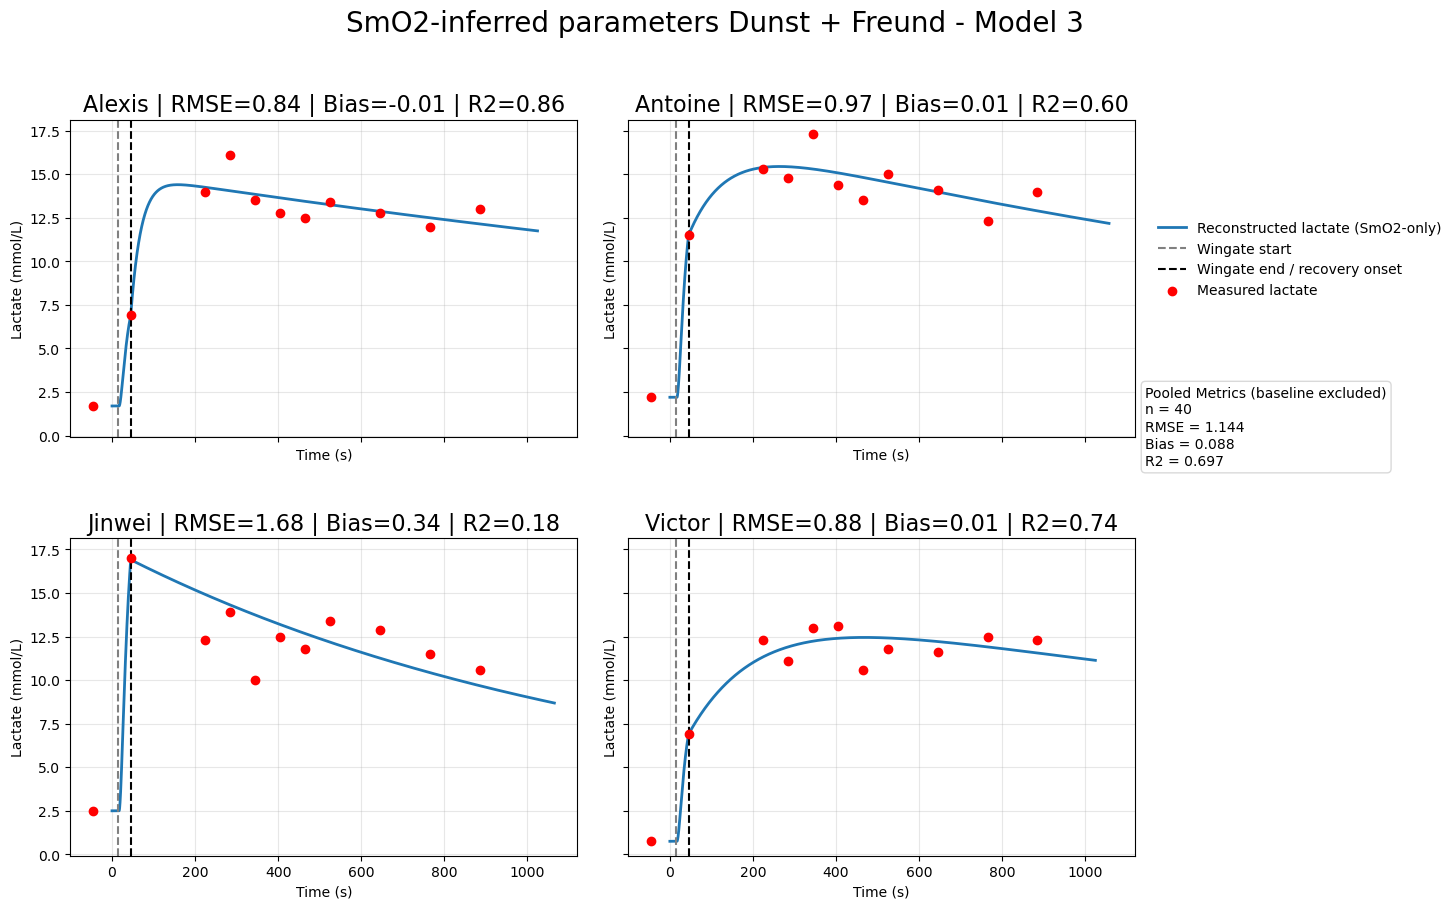

In [58]:

def fast_exponential_rise(frac, k=5.0):
    """
    Fast rise with saturation.
    frac must be between 0 and 1.
    """
    frac = np.clip(frac, 0, 1)
    rise = 1 - np.exp(-k * frac)
    rise = rise / (1 - np.exp(-k))
    return rise


def reference_exercise_end_delta(delta_peak, start_time_s=15.0,
                                 wingate_duration_s=30.0, t_peak_s=225.0):
    """
    Reference end-of-exercise delta used to anchor the Dunst curve.
    """
    rise_start = start_time_s + TALAC_S
    recovery_start = start_time_s + wingate_duration_s

    if recovery_start <= rise_start:
        return 0.0

    frac_end = (recovery_start - rise_start) / (t_peak_s - rise_start)
    return float(delta_peak * fast_exponential_rise(frac_end, k=K_RISE))


def dunst_exercise_delta(t_after_start, delta_end_target,
                         wingate_duration_s=30.0, delay_s=2.0,
                         k3=EXERCISE_K3, k4=EXERCISE_K4):
    """
    Dunst et al. (2023)-style sprint model for lactate accumulation relative to baseline.
    The curve is calibrated to be 0 at the appearance delay and to reach the chosen
    end-of-exercise delta at Wingate end.
    """
    t_after_start = np.asarray(t_after_start, dtype=float)
    t_effective = np.clip(t_after_start - delay_s, 0.0, max(wingate_duration_s - delay_s, 0.0))

    g0 = -(1.0 / k3) + (1.0 / k4)
    g_end = (
        -(1.0 / k3) * np.exp(-k3 * max(wingate_duration_s - delay_s, 0.0))
        + (1.0 / k4) * np.exp(-k4 * max(wingate_duration_s - delay_s, 0.0))
    )
    denom = g_end - g0
    if np.isclose(denom, 0.0):
        return np.full_like(t_effective, float(delta_end_target), dtype=float)

    B = float(delta_end_target) / denom
    C = -B * g0
    delta = B * (
        -(1.0 / k3) * np.exp(-k3 * t_effective)
        + (1.0 / k4) * np.exp(-k4 * t_effective)
    ) + C
    return np.maximum(delta, 0.0)


def fallback_recovery_onset(la_base, delta_peak,
                            start_time_s=15.0, wingate_duration_s=30.0,
                            t_peak_s=225.0):
    """
    Fallback handoff at end of exercise if SmO2-trained model cannot estimate it.
    """
    exercise_end_target = reference_exercise_end_delta(
        delta_peak=delta_peak,
        start_time_s=start_time_s,
        wingate_duration_s=wingate_duration_s,
        t_peak_s=t_peak_s,
    )
    delta_end = dunst_exercise_delta(
        t_after_start=wingate_duration_s,
        delta_end_target=exercise_end_target,
        wingate_duration_s=wingate_duration_s,
        delay_s=EXERCISE_DELAY_S,
        k3=EXERCISE_K3,
        k4=EXERCISE_K4,
    )
    return float(la_base + float(np.asarray(delta_end).item()))


def freund_recovery_rewrite(t_after_recovery, la_base, la_recovery_onset,
                            delta_peak, gamma1=1/300, gamma2=1/2000):
    """
    Recovery model (Durand et al., 2021 rewrite of Freund et al.).
    """
    t_after_recovery = np.maximum(t_after_recovery, 0)
    return (
        la_recovery_onset
        + (delta_peak + la_base - la_recovery_onset) * (1 - np.exp(-gamma1 * t_after_recovery))
        + (-delta_peak) * (1 - np.exp(-gamma2 * t_after_recovery))
    )


def fit_recovery_gammas(lac_subject, la_base, la_recovery_onset, delta_peak,
                        gamma1_default=1/300, gamma2_default=1/2000):
    """
    Fit subject-specific recovery gammas from measured post-exercise lactate points.
    Time in the lactate table is assumed to be minutes after Wingate end.

    Returns:
    - gamma1_fit
    - gamma2_fit
    - recovery_rmse_fit
    - n_recovery_points
    """
    rec = lac_subject.copy()
    rec = rec[pd.to_numeric(rec["Time"], errors="coerce").notna()]
    rec = rec[pd.to_numeric(rec["[La]"], errors="coerce").notna()]
    rec = rec[rec["Time"] >= 0].copy()

    if rec.empty:
        return float(gamma1_default), float(gamma2_default), np.nan, 0

    rec["t_rec_s"] = rec["Time"].astype(float) * 60.0
    rec = rec.sort_values("t_rec_s")

    t_data = rec["t_rec_s"].to_numpy(float)
    y_data = rec["[La]"].to_numpy(float)

    n_pts = int(len(rec))
    if n_pts < 3 or np.unique(t_data).size < 3:
        return float(gamma1_default), float(gamma2_default), np.nan, n_pts

    def rec_model(t, g1, g2):
        return freund_recovery_rewrite(
            t_after_recovery=t,
            la_base=la_base,
            la_recovery_onset=la_recovery_onset,
            delta_peak=delta_peak,
            gamma1=g1,
            gamma2=g2,
        )

    try:
        p0 = [float(gamma1_default), float(gamma2_default)]
        bounds = ([1/10000, 1/10000], [1/20, 1/20])
        popt, _ = curve_fit(rec_model, t_data, y_data, p0=p0, bounds=bounds, maxfev=50000)

        gamma1_fit = float(popt[0])
        gamma2_fit = float(popt[1])
        y_pred_fit = rec_model(t_data, gamma1_fit, gamma2_fit)
        rmse_fit = float(np.sqrt(np.mean((y_data - y_pred_fit) ** 2)))

        return gamma1_fit, gamma2_fit, rmse_fit, n_pts

    except Exception:
        return float(gamma1_default), float(gamma2_default), np.nan, n_pts


def clip_gamma(x):
    return float(np.clip(x, 1/10000, 1/20))


def fit_linear_model(df, feature_cols, target_col):
    """
    Fit a linear model with intercept using numpy least squares.
    """
    d = df.dropna(subset=feature_cols + [target_col]).copy()
    if len(d) < 2:
        return None

    X = d[feature_cols].to_numpy(float)
    y = d[target_col].to_numpy(float)
    X_aug = np.column_stack([np.ones(len(X)), X])

    coef, *_ = np.linalg.lstsq(X_aug, y, rcond=None)
    return {
        "intercept": float(coef[0]),
        "weights": coef[1:].astype(float),
        "feature_cols": feature_cols,
        "n_samples": int(len(d)),
    }


def predict_linear(model, feature_dict):
    if model is None:
        return np.nan
    x = np.array([feature_dict[c] for c in model["feature_cols"]], dtype=float)
    return float(model["intercept"] + np.dot(model["weights"], x))


def evaluate_recovery_rmse(lac_subject, la_base, la_recovery_onset, delta_peak, gamma1, gamma2):
    """
    Evaluate recovery-only RMSE at measured post-exercise points (Time >= 0).
    """
    rec = lac_subject.copy()
    rec = rec[pd.to_numeric(rec["Time"], errors="coerce").notna()]
    rec = rec[pd.to_numeric(rec["[La]"], errors="coerce").notna()]
    rec = rec[rec["Time"] >= 0].copy()

    if rec.empty:
        return np.nan, 0

    t = rec["Time"].astype(float).to_numpy() * 60.0
    y = rec["[La]"].astype(float).to_numpy()
    y_hat = freund_recovery_rewrite(
        t_after_recovery=t,
        la_base=la_base,
        la_recovery_onset=la_recovery_onset,
        delta_peak=delta_peak,
        gamma1=gamma1,
        gamma2=gamma2,
    )
    return float(np.sqrt(np.mean((y - y_hat) ** 2))), int(len(rec))


def reconstruct_lactate_curve(sm_full, la_base, delta_peak,
                              la_recovery_onset_value,
                              gamma1_recovery,
                              gamma2_recovery,
                              start_time_s=15.0,
                              wingate_duration_s=30.0):
    """
    Reconstruct the full lactate curve from SmO2-driven parameters.
    """
    pred = sm_full[["Time"]].copy()
    pred["La_est"] = np.nan

    rise_start = start_time_s + TALAC_S
    recovery_start = start_time_s + wingate_duration_s
    exercise_end_target = max(float(la_recovery_onset_value) - float(la_base), 0.0)

    for i, t in enumerate(pred["Time"].to_numpy(float)):
        if t < rise_start:
            pred.loc[i, "La_est"] = la_base
        elif t <= recovery_start:
            delta_exercise = dunst_exercise_delta(
                t_after_start=t - start_time_s,
                delta_end_target=exercise_end_target,
                wingate_duration_s=wingate_duration_s,
                delay_s=EXERCISE_DELAY_S,
                k3=EXERCISE_K3,
                k4=EXERCISE_K4,
            )
            pred.loc[i, "La_est"] = la_base + float(np.asarray(delta_exercise).item())
        else:
            t_after_recovery = t - recovery_start
            pred.loc[i, "La_est"] = freund_recovery_rewrite(
                t_after_recovery=t_after_recovery,
                la_base=la_base,
                la_recovery_onset=la_recovery_onset_value,
                delta_peak=delta_peak,
                gamma1=gamma1_recovery,
                gamma2=gamma2_recovery,
            )

    return pred


def summarize_lactate_subject(lac_subject):
    """
    Extract measured lactate summary for plotting/training labels.
    """
    lac_subject = lac_subject.sort_values("Time").copy()

    base_row = lac_subject[lac_subject["Time"] == -1]
    la_baseline = float(base_row["[La]"].iloc[0]) if not base_row.empty else np.nan

    rec_onset_row = lac_subject[lac_subject["Time"] == 0]
    la_recovery_onset = float(rec_onset_row["[La]"].iloc[0]) if not rec_onset_row.empty else np.nan

    # Peak can occur exactly at recovery onset (Time == 0).
    post = lac_subject[lac_subject["Time"] >= 0]
    if post.empty:
        la_peak = np.nan
        t_peak = np.nan
        delta_peak = np.nan
    else:
        idx_peak = post["[La]"].idxmax()
        la_peak = float(post.loc[idx_peak, "[La]"])
        t_peak = float(post.loc[idx_peak, "Time"])
        delta_peak = la_peak - la_baseline if np.isfinite(la_baseline) else np.nan

    return {
        "La_baseline": la_baseline,
        "La_recovery_onset_measured": la_recovery_onset,
        "La_peak": la_peak,
        "Time_peak_min": t_peak,
        "Delta_La_peak": delta_peak,
    }


# 4) LOAD MEASURED LACTATE TABLE
lac_all = pd.read_excel(XLS_FILE, sheet_name=SHEET_NAME)
lac_all.columns = [str(c).strip() for c in lac_all.columns]
lac_all["Time"] = pd.to_numeric(lac_all["Time"], errors="coerce")
lac_all["[La]"] = pd.to_numeric(lac_all["[La]"], errors="coerce")


# 5A) BUILD SUBJECT TABLE + TARGETS FOR SmO2-ONLY PARAMETER MODELS
subject_rows = []
sm_store = {}

for subject, csv_file in CSV_FILES.items():
    sm = load_trainred_csv(csv_file)
    sm_store[subject] = sm.copy()

    sm0 = MANUAL_SMO2_BASELINE[subject]
    feat = extract_features_from_manual_baseline(
        sm_df=sm,
        sm0=sm0,
        start_time_s=START_TIME_S,
        duration_s=WINGATE_DURATION,
    )

    delta_peak_pred = (
        B0
        + B1 * feat["AUC_30s"]
        + B2 * feat["tau_SmO2"]
        + B3 * feat["dSmO2_max"]
        + B4 * feat["slope_0_10"]
    )
    delta_peak_pred = max(delta_peak_pred, 0.0)

    lac_sub = lac_all[lac_all["Name"].str.lower() == subject.lower()].copy()
    lac_summary = summarize_lactate_subject(lac_sub)

    if USE_MEASURED_LA_BASELINE and np.isfinite(lac_summary["La_baseline"]):
        la_base = float(lac_summary["La_baseline"])
    else:
        la_base = float(LA_BASELINE_ASSUMED)

    la_rec_measured = lac_summary["La_recovery_onset_measured"]
    la_rec_for_fit = (
        float(la_rec_measured)
        if np.isfinite(la_rec_measured)
        else fallback_recovery_onset(
            la_base=la_base,
            delta_peak=delta_peak_pred,
            start_time_s=START_TIME_S,
            wingate_duration_s=WINGATE_DURATION,
            t_peak_s=T_PEAK_S_FIXED,
        )
    )

    # Target recovery gammas obtained from measured lactate dynamics.
    gamma1_obs, gamma2_obs, rmse_obs, n_obs = fit_recovery_gammas(
        lac_subject=lac_sub,
        la_base=la_base,
        la_recovery_onset=la_rec_for_fit,
        delta_peak=delta_peak_pred,
        gamma1_default=GAMMA1_RECOVERY,
        gamma2_default=GAMMA2_RECOVERY,
    )

    subject_rows.append({
        "id": subject,
        "SmO2_baseline_manual": sm0,
        "AUC_30s": feat["AUC_30s"],
        "tau_SmO2": feat["tau_SmO2"],
        "dSmO2_max": feat["dSmO2_max"],
        "slope_0_10": feat["slope_0_10"],
        "Delta_La_peak_pred": delta_peak_pred,
        "La_baseline_used": la_base,
        "La_recovery_onset_measured": la_rec_measured,
        "gamma1_recovery_obs": gamma1_obs,
        "gamma2_recovery_obs": gamma2_obs,
        "Recovery_fit_RMSE_obs": rmse_obs,
        "Recovery_points_n_obs": n_obs,
        "La_peak_measured": lac_summary["La_peak"],
        "Delta_La_peak_measured": lac_summary["Delta_La_peak"],
    })

subject_df = pd.DataFrame(subject_rows)


# 5B) FIT PARAMETER MODELS FROM SmO2 FEATURES (SmO2-ONLY GUIDANCE)
feature_cols = [
    "AUC_30s",
    "tau_SmO2",
    "dSmO2_max",
    "slope_0_10",
    "Delta_La_peak_pred",
]

model_la_rec = fit_linear_model(subject_df, feature_cols, "La_recovery_onset_measured")
model_gamma1 = fit_linear_model(subject_df, feature_cols, "gamma1_recovery_obs")
model_gamma2 = fit_linear_model(subject_df, feature_cols, "gamma2_recovery_obs")

print("\n===== SmO2 PARAMETER MODELS =====")
print(f"La_recovery_onset model samples: {0 if model_la_rec is None else model_la_rec['n_samples']}")
print(f"gamma1 model samples: {0 if model_gamma1 is None else model_gamma1['n_samples']}")
print(f"gamma2 model samples: {0 if model_gamma2 is None else model_gamma2['n_samples']}")


# 5C) APPLY FULL SmO2-ONLY LACTATE RECONSTRUCTION
rows = []
curve_store = {}

for _, srow in subject_df.iterrows():
    sid = srow["id"]
    sm = sm_store[sid].copy()

    la_base = float(srow["La_baseline_used"])
    delta_peak_pred = float(srow["Delta_La_peak_pred"])

    feat_map = {c: float(srow[c]) for c in feature_cols}

    la_recovery_onset_pred = predict_linear(model_la_rec, feat_map)
    if not np.isfinite(la_recovery_onset_pred):
        la_recovery_onset_pred = fallback_recovery_onset(
            la_base=la_base,
            delta_peak=delta_peak_pred,
            start_time_s=START_TIME_S,
            wingate_duration_s=WINGATE_DURATION,
            t_peak_s=T_PEAK_S_FIXED,
        )

    # Physiological consistency: hand-off should stay below model peak reference.
    la_peak_ref = la_base + delta_peak_pred
    la_recovery_onset_pred = float(np.clip(la_recovery_onset_pred, la_base, la_peak_ref - 1e-6))

    gamma1_pred = clip_gamma(predict_linear(model_gamma1, feat_map))
    gamma2_pred = clip_gamma(predict_linear(model_gamma2, feat_map))

    pred_curve = reconstruct_lactate_curve(
        sm_full=sm,
        la_base=la_base,
        delta_peak=delta_peak_pred,
        la_recovery_onset_value=la_recovery_onset_pred,
        gamma1_recovery=gamma1_pred,
        gamma2_recovery=gamma2_pred,
        start_time_s=START_TIME_S,
        wingate_duration_s=WINGATE_DURATION,
    )

    lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()
    rec_rmse_eval, rec_n_eval = evaluate_recovery_rmse(
        lac_subject=lac_sub,
        la_base=la_base,
        la_recovery_onset=la_recovery_onset_pred,
        delta_peak=delta_peak_pred,
        gamma1=gamma1_pred,
        gamma2=gamma2_pred,
    )

    curve_store[sid] = pred_curve

    rows.append({
        "id": sid,
        "SmO2_baseline_manual": srow["SmO2_baseline_manual"],
        "AUC_30s": srow["AUC_30s"],
        "tau_SmO2": srow["tau_SmO2"],
        "dSmO2_max": srow["dSmO2_max"],
        "slope_0_10": srow["slope_0_10"],
        "Delta_La_peak_pred": delta_peak_pred,
        "La_baseline_used": la_base,
        "La_recovery_onset_pred_smo2": la_recovery_onset_pred,
        "gamma1_recovery_pred_smo2": gamma1_pred,
        "gamma2_recovery_pred_smo2": gamma2_pred,
        "Recovery_RMSE_eval": rec_rmse_eval,
        "Recovery_points_n_eval": rec_n_eval,
        "La_peak_pred": la_base + delta_peak_pred,
        "Handoff_clipped_to_peak": bool(la_recovery_onset_pred >= la_peak_ref - 1e-5),
        "T_peak_min_fixed": T_PEAK_MIN_FIXED,
        "La_recovery_onset_measured": srow["La_recovery_onset_measured"],
        "La_peak_measured": srow["La_peak_measured"],
        "Delta_La_peak_measured": srow["Delta_La_peak_measured"],
    })

model3_df = pd.DataFrame(rows)

print("\n===== MODEL 3 SUMMARY (SmO2-ONLY PARAMETERS) =====")
print(model3_df)

print("\n===== SmO2-PREDICTED RECOVERY PARAMETERS =====")
print(model3_df[[
    "id",
    "La_recovery_onset_pred_smo2",
    "gamma1_recovery_pred_smo2",
    "gamma2_recovery_pred_smo2",
    "Recovery_RMSE_eval",
    "Recovery_points_n_eval",
    "Handoff_clipped_to_peak",
]])


# 6) PLOTS
n_subjects = len(model3_df)
ncols = 2
nrows = int(np.ceil(n_subjects / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.6 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

pooled_true = []
pooled_pred = []

for ax, (_, row) in zip(axes, model3_df.iterrows()):
    sid = row["id"]
    pred_curve = curve_store[sid].copy()
    t_pred = pred_curve["Time"].to_numpy(float)
    y_pred_curve = pred_curve["La_est"].to_numpy(float)

    ax.plot(pred_curve["Time"], pred_curve["La_est"], label="Reconstructed lactate (SmO2-only)", linewidth=2)
    ax.axvline(START_TIME_S, linestyle="--", label="Wingate start", color="gray")
    ax.axvline(END_TIME_S, linestyle="--", color="black", label="Wingate end / recovery onset")

    lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()
    panel_true = []
    panel_pred = []
    if not lac_sub.empty:
        abs_times = []
        la_vals = []
        time_rel = []

        for _, rr in lac_sub.iterrows():
            t_rel_min = rr["Time"]
            la_val = rr["[La]"]

            if pd.isna(t_rel_min) or pd.isna(la_val):
                continue

            if t_rel_min == -1:
                t_abs = START_TIME_S - 60
            else:
                t_abs = END_TIME_S + t_rel_min * 60

            abs_times.append(t_abs)
            la_vals.append(la_val)
            time_rel.append(t_rel_min)

        ax.scatter(abs_times, la_vals, color="red", label="Measured lactate", zorder=3)

        if len(abs_times) > 0:
            panel_pred = np.interp(np.asarray(abs_times, dtype=float), t_pred, y_pred_curve)
            panel_true = np.asarray(la_vals, dtype=float)

            time_rel_arr = np.asarray(time_rel, dtype=float)
            valid_mask = time_rel_arr != -1
            panel_true = panel_true[valid_mask]
            panel_pred = panel_pred[valid_mask]

            if len(panel_true) > 0:
                pooled_true.extend(panel_true.tolist())
                pooled_pred.extend(panel_pred.tolist())

    if len(panel_true) > 0:
        rmse_panel = float(np.sqrt(np.mean((panel_pred - panel_true) ** 2)) )
        bias_panel = float(np.mean(panel_pred - panel_true))
        ss_res = float(np.sum((panel_true - panel_pred) ** 2))
        ss_tot = float(np.sum((panel_true - np.mean(panel_true)) ** 2))
        r2_panel = np.nan if np.isclose(ss_tot, 0.0) else float(1 - ss_res / ss_tot)
        r2_str = f"{r2_panel:.2f}" if np.isfinite(r2_panel) else "nan"
        ax.set_title(f"{sid} | RMSE={rmse_panel:.2f} | Bias={bias_panel:.2f} | R2={r2_str}", fontsize=16)
    else:
        ax.set_title(f"{sid} | RMSE=nan | Bias=nan | R2=nan", fontsize=16)

    ax.grid(True, alpha=0.3)

for i in range(n_subjects, len(axes)):
    axes[i].axis("off")

for ax in axes[:n_subjects]:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Lactate (mmol/L)")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax_idx = min(n_subjects - 1, ncols - 1)
legend_x = 1.02
if handles:
    axes[legend_ax_idx].legend(handles, labels, loc="center left", bbox_to_anchor=(legend_x, 0.56), frameon=False)

pooled_n = len(pooled_true)
if pooled_n > 0:
    pooled_true = np.asarray(pooled_true, dtype=float)
    pooled_pred = np.asarray(pooled_pred, dtype=float)
    pooled_rmse = float(np.sqrt(np.mean((pooled_pred - pooled_true) ** 2)))
    pooled_bias = float(np.mean(pooled_pred - pooled_true))
    pooled_ss_res = float(np.sum((pooled_true - pooled_pred) ** 2))
    pooled_ss_tot = float(np.sum((pooled_true - np.mean(pooled_true)) ** 2))
    pooled_r2 = np.nan if np.isclose(pooled_ss_tot, 0.0) else float(1 - pooled_ss_res / pooled_ss_tot)
    pooled_r2_str = f"{pooled_r2:.3f}" if np.isfinite(pooled_r2) else "nan"
    pooled_text = (
        f"Pooled Metrics (baseline excluded)\n"
        f"n = {pooled_n}\n"
        f"RMSE = {pooled_rmse:.3f}\n"
        f"Bias = {pooled_bias:.3f}\n"
        f"R2 = {pooled_r2_str}"
    )
else:
    pooled_text = "Pooled (baseline excluded): no valid points"

axes[legend_ax_idx].text(
    legend_x,
    -0.10,
    pooled_text,
    transform=axes[legend_ax_idx].transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    linespacing=1.3,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "lightgray"},
)

fig.suptitle("SmO2-inferred parameters Dunst + Freund - Model 3", y=1.02, fontsize=20)
fig.subplots_adjust(left=0.07, right=0.78, top=0.90, bottom=0.10, wspace=0.10, hspace=0.32)
plt.show()



===== SUBJECT-LEVEL ERROR METRICS (vs true lactate) =====
        id  n_points_eval  RMSE_all  Bias_all    R2_all
0   Alexis             11  0.797792 -0.010082  0.955873
1  Antoine             11  0.920540  0.013122  0.939723
2   Jinwei             11  1.604838  0.306170  0.776998
3   Victor             11  0.838296  0.011069  0.942639

===== POOLED ERROR METRICS (recovery only, Time > 0) =====
n = 36
RMSE = 1.206 mmol/L
Bias = 0.100 mmol/L
R2   = 0.365


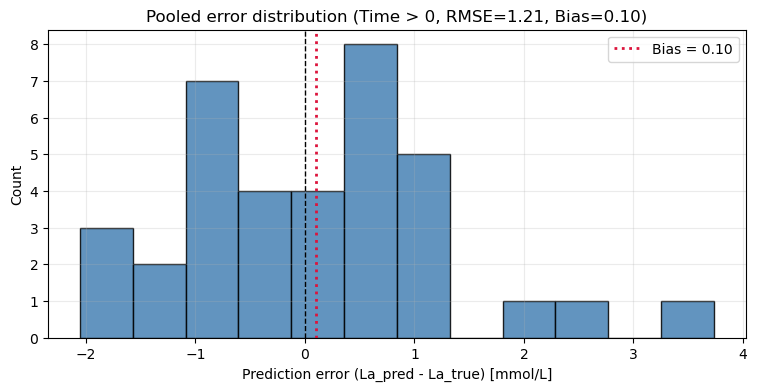

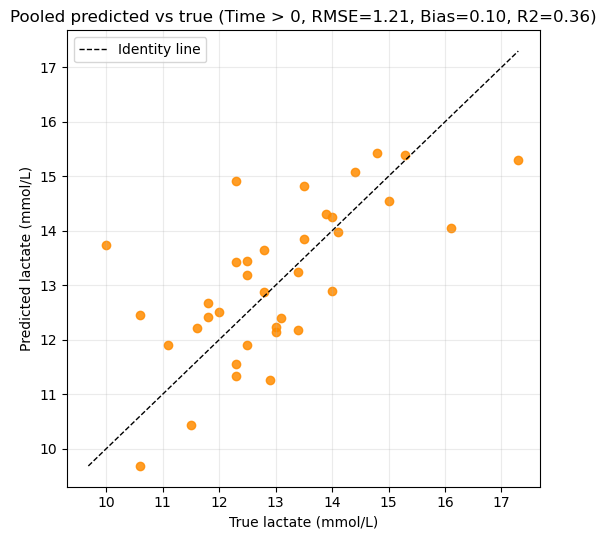


===== PEAK IN RECOVERY RMSE =====
Time-to-peak RMSE = 1.361 min
Peak value RMSE   = 1.301 mmol/L

===== PEAK IN RECOVERY (measured vs predicted) =====
        id  t_peak_meas_min  t_peak_pred_min  la_peak_meas  la_peak_pred
0   Alexis              4.0         1.889000          16.1     14.399724
1  Antoine              5.0         3.643167          17.3     15.443532
2   Jinwei              0.0         0.000000          17.0     16.906041
3   Victor              6.0         7.052167          13.1     12.448893


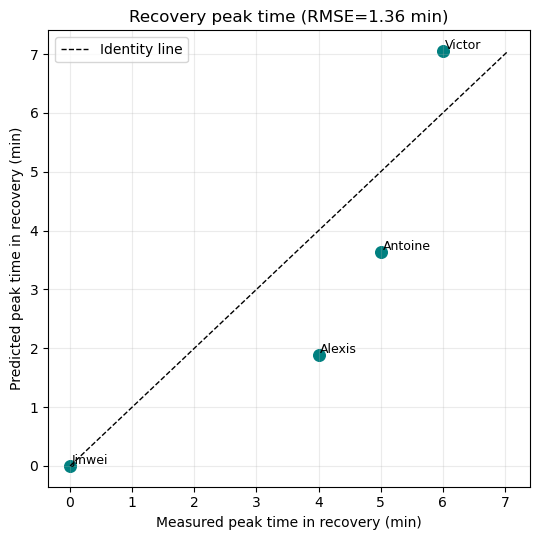

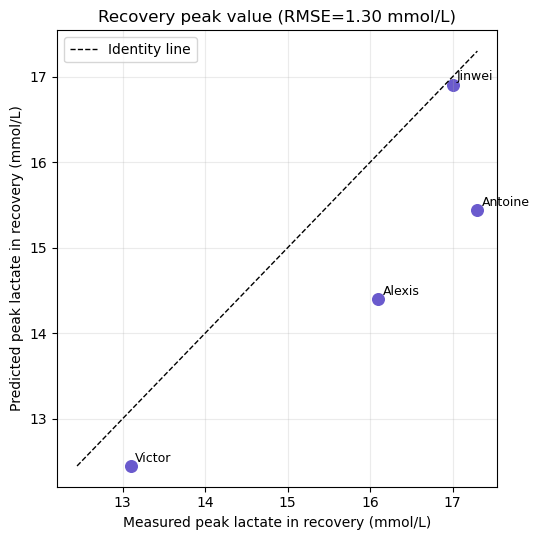

In [59]:
# 7) METRICS VS TRUE LACTATE (MEASURED)

def lactate_samples_to_absolute_seconds(lac_subject, start_time_s, end_time_s):
    """
    Convert lactate sampling times to absolute time used by SmO2 traces.
    Convention:
    - Time == -1: baseline, placed at start_time_s - 60
    - Time >= 0: minutes after Wingate end
    """
    ls = lac_subject.copy()
    ls = ls[pd.to_numeric(ls["Time"], errors="coerce").notna()]
    ls = ls[pd.to_numeric(ls["[La]"], errors="coerce").notna()]

    if ls.empty:
        return pd.DataFrame(columns=["Time", "Time_abs_s", "La_true"])

    ls["Time"] = ls["Time"].astype(float)
    ls["La_true"] = ls["[La]"].astype(float)
    ls["Time_abs_s"] = np.where(
        ls["Time"] == -1,
        start_time_s - 60,
        end_time_s + ls["Time"] * 60.0,
    )
    return ls[["Time", "Time_abs_s", "La_true"]].sort_values("Time_abs_s").reset_index(drop=True)


def safe_pearson_r(y_true, y_pred):
    """Compute Pearson correlation with guards for short or constant series."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if y_true.size < 2 or y_pred.size < 2:
        return np.nan
    if np.allclose(np.std(y_true), 0.0) or np.allclose(np.std(y_pred), 0.0):
        return np.nan

    return float(np.corrcoef(y_true, y_pred)[0, 1])


def safe_r2(y_true, y_pred):
    """Compute coefficient of determination with zero-variance guard."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return float(1 - ss_res / ss_tot)


def evaluate_subject_curve(pred_curve, lac_subject, start_time_s, end_time_s):
    """
    Compare reconstructed curve to measured lactate at measured sampling times.
    Uses linear interpolation on reconstructed curve.
    """
    measured = lactate_samples_to_absolute_seconds(lac_subject, start_time_s, end_time_s)
    if measured.empty:
        return measured, {
            "n_points": 0,
            "RMSE": np.nan,
            "Bias": np.nan,
            "R2": np.nan,
        }

    t_pred = pred_curve["Time"].to_numpy(float)
    y_pred = pred_curve["La_est"].to_numpy(float)

    measured["La_pred"] = np.interp(
        measured["Time_abs_s"].to_numpy(float),
        t_pred,
        y_pred,
    )

    measured["Error"] = measured["La_pred"] - measured["La_true"]
    measured["Absolute_error"] = np.abs(measured["Error"])
    measured["Squared_error"] = measured["Error"] ** 2

    y_true = measured["La_true"].to_numpy(float)
    y_hat = measured["La_pred"].to_numpy(float)

    metrics = {
        "n_points": int(len(measured)),
        "RMSE": float(np.sqrt(np.mean((y_hat - y_true) ** 2))),
        "Bias": float(np.mean(y_hat - y_true)),
        "R2": safe_r2(y_true, y_hat),
    }
    return measured, metrics


# Per-subject and pooled metrics
subject_eval_rows = []
all_pairs = []

for sid in model3_df["id"]:
    pred_curve = curve_store[sid].copy()
    lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()

    eval_table, met = evaluate_subject_curve(
        pred_curve=pred_curve,
        lac_subject=lac_sub,
        start_time_s=START_TIME_S,
        end_time_s=END_TIME_S,
    )

    if not eval_table.empty:
        tmp = eval_table[["Time", "Time_abs_s", "La_true", "La_pred", "Error", "Absolute_error"]].copy()
        # Exclude baseline (-1) and hand-off (0) from pooled error analysis.
        tmp = tmp[tmp["Time"] > 0].copy()
        if not tmp.empty:
            tmp["id"] = sid
            all_pairs.append(tmp)

    subject_eval_rows.append({
        "id": sid,
        "n_points_eval": met["n_points"],
        "RMSE_all": met["RMSE"],
        "Bias_all": met["Bias"],
        "R2_all": met["R2"],
    })

subject_metrics_df = pd.DataFrame(subject_eval_rows)

# Make this cell re-runnable by removing previous metric columns before merge.
metric_cols = ["n_points_eval", "RMSE_all", "Bias_all", "R2_all", "MAE_all", "R_all"]
existing_metric_cols = [c for c in metric_cols if c in model3_df.columns]
if len(existing_metric_cols) > 0:
    model3_df = model3_df.drop(columns=existing_metric_cols)

model3_df = model3_df.merge(subject_metrics_df, on="id", how="left")

print("\n===== SUBJECT-LEVEL ERROR METRICS (vs true lactate) =====")
print(model3_df[[
    "id",
    "n_points_eval",
    "RMSE_all",
    "Bias_all",
    "R2_all",
]])

if len(all_pairs) > 0:
    pooled = pd.concat(all_pairs, ignore_index=True)
    y_true_pool = pooled["La_true"].to_numpy(float)
    y_pred_pool = pooled["La_pred"].to_numpy(float)

    pooled_rmse = float(np.sqrt(np.mean((y_pred_pool - y_true_pool) ** 2)))
    pooled_bias = float(np.mean(y_pred_pool - y_true_pool))
    pooled_r2 = safe_r2(y_true_pool, y_pred_pool)

    print("\n===== POOLED ERROR METRICS (recovery only, Time > 0) =====")
    print(f"n = {len(pooled)}")
    print(f"RMSE = {pooled_rmse:.3f} mmol/L")
    print(f"Bias = {pooled_bias:.3f} mmol/L")
    print(f"R2   = {pooled_r2:.3f}" if np.isfinite(pooled_r2) else "R2   = nan")

    # Pooled residual histogram
    plt.figure(figsize=(9, 4))
    plt.hist(pooled["Error"], bins=12, color="steelblue", edgecolor="black", alpha=0.85)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(pooled_bias, color="crimson", linestyle=":", linewidth=2, label=f"Bias = {pooled_bias:.2f}")
    plt.xlabel("Prediction error (La_pred - La_true) [mmol/L]")
    plt.ylabel("Count")
    plt.title(f"Pooled error distribution (Time > 0, RMSE={pooled_rmse:.2f}, Bias={pooled_bias:.2f})")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    # Pooled predicted-vs-true scatter
    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(pooled["La_true"], pooled["La_pred"], alpha=0.85, color="darkorange")
    lim_min = float(min(pooled["La_true"].min(), pooled["La_pred"].min()))
    lim_max = float(max(pooled["La_true"].max(), pooled["La_pred"].max()))
    plt.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, label="Identity line")
    plt.xlabel("True lactate (mmol/L)")
    plt.ylabel("Predicted lactate (mmol/L)")
    plt.title(f"Pooled predicted vs true (Time > 0, RMSE={pooled_rmse:.2f}, Bias={pooled_bias:.2f}, R2={pooled_r2:.2f})")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Peak lactate in recovery: RMSE of time and value
    peak_rows = []
    for sid in model3_df["id"]:
        lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()
        lac_sub = lac_sub[pd.to_numeric(lac_sub["Time"], errors="coerce").notna()]
        lac_sub = lac_sub[pd.to_numeric(lac_sub["[La]"], errors="coerce").notna()]

        # Measured peak from recovery onset onward (include handoff Time == 0).
        measured_rec = lac_sub[lac_sub["Time"] >= 0].copy()
        if measured_rec.empty:
            continue

        idx_meas = measured_rec["[La]"].idxmax()
        t_peak_meas_min = float(measured_rec.loc[idx_meas, "Time"])
        la_peak_meas = float(measured_rec.loc[idx_meas, "[La]"])

        # Predicted peak from recovery onset onward (include t == end of exercise).
        pred_rec = curve_store[sid].copy()
        pred_rec = pred_rec[pred_rec["Time"] >= END_TIME_S].copy()
        if pred_rec.empty:
            continue

        idx_pred = pred_rec["La_est"].idxmax()
        t_peak_pred_abs_s = float(pred_rec.loc[idx_pred, "Time"])
        t_peak_pred_min = (t_peak_pred_abs_s - END_TIME_S) / 60.0
        la_peak_pred_rec = float(pred_rec.loc[idx_pred, "La_est"])

        peak_rows.append({
            "id": sid,
            "t_peak_meas_min": t_peak_meas_min,
            "t_peak_pred_min": t_peak_pred_min,
            "la_peak_meas": la_peak_meas,
            "la_peak_pred": la_peak_pred_rec,
        })

    if len(peak_rows) > 0:
        peak_df = pd.DataFrame(peak_rows)
        peak_df["t_peak_err_min"] = peak_df["t_peak_pred_min"] - peak_df["t_peak_meas_min"]
        peak_df["la_peak_err"] = peak_df["la_peak_pred"] - peak_df["la_peak_meas"]

        rmse_t_peak = float(np.sqrt(np.mean(peak_df["t_peak_err_min"] ** 2)))
        rmse_la_peak = float(np.sqrt(np.mean(peak_df["la_peak_err"] ** 2)))

        print("\n===== PEAK IN RECOVERY RMSE =====")
        print(f"Time-to-peak RMSE = {rmse_t_peak:.3f} min")
        print(f"Peak value RMSE   = {rmse_la_peak:.3f} mmol/L")

        print("\n===== PEAK IN RECOVERY (measured vs predicted) =====")
        print(peak_df[[
            "id",
            "t_peak_meas_min",
            "t_peak_pred_min",
            "la_peak_meas",
            "la_peak_pred",
        ]])

        # Peak time: measured vs predicted
        plt.figure(figsize=(5.5, 5.5))
        plt.scatter(peak_df["t_peak_meas_min"], peak_df["t_peak_pred_min"], color="teal", s=70)
        for _, rr in peak_df.iterrows():
            plt.text(rr["t_peak_meas_min"] + 0.03, rr["t_peak_pred_min"] + 0.03, rr["id"], fontsize=9)
        tmin = float(min(peak_df["t_peak_meas_min"].min(), peak_df["t_peak_pred_min"].min()))
        tmax = float(max(peak_df["t_peak_meas_min"].max(), peak_df["t_peak_pred_min"].max()))
        plt.plot([tmin, tmax], [tmin, tmax], "k--", linewidth=1, label="Identity line")
        plt.xlabel("Measured peak time in recovery (min)")
        plt.ylabel("Predicted peak time in recovery (min)")
        plt.title(f"Recovery peak time (RMSE={rmse_t_peak:.2f} min)")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Peak value: measured vs predicted
        plt.figure(figsize=(5.5, 5.5))
        plt.scatter(peak_df["la_peak_meas"], peak_df["la_peak_pred"], color="slateblue", s=70)
        for _, rr in peak_df.iterrows():
            plt.text(rr["la_peak_meas"] + 0.05, rr["la_peak_pred"] + 0.05, rr["id"], fontsize=9)
        vmin = float(min(peak_df["la_peak_meas"].min(), peak_df["la_peak_pred"].min()))
        vmax = float(max(peak_df["la_peak_meas"].max(), peak_df["la_peak_pred"].max()))
        plt.plot([vmin, vmax], [vmin, vmax], "k--", linewidth=1, label="Identity line")
        plt.xlabel("Measured peak lactate in recovery (mmol/L)")
        plt.ylabel("Predicted peak lactate in recovery (mmol/L)")
        plt.title(f"Recovery peak value (RMSE={rmse_la_peak:.2f} mmol/L)")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo valid subjects for recovery peak RMSE computation.")
else:
    print("\nNo recovery measured lactate points available for pooled metrics (Time > 0).")

In [60]:
# 8) PEAK VALUE AND PEAK TIME ERROR METRICS TABLE (RMSE, Bias, R2)

peak_rows = []

for _, row in model3_df.iterrows():
    sid = row["id"]
    pred_curve = curve_store[sid].copy()
    
    # Measured peak from post-exercise points (Time > 0)
    lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()
    post = lac_sub[lac_sub["Time"] > 0].copy()
    if post.empty:
        la_peak_measured = np.nan
        t_peak_measured_min = np.nan
    else:
        idx_peak = post["[La]"].idxmax()
        la_peak_measured = float(post.loc[idx_peak, "[La]"])
        t_peak_measured_min = float(post.loc[idx_peak, "Time"])
    
    # Predicted peak from recovery phase
    pred_rec = pred_curve[pred_curve["Time"] >= END_TIME_S].copy()
    if pred_rec.empty:
        la_peak_pred = np.nan
        t_peak_pred_min = np.nan
    else:
        idx_pred = pred_rec["La_est"].idxmax()
        t_peak_pred_abs_s = float(pred_rec.loc[idx_pred, "Time"])
        t_peak_pred_min = (t_peak_pred_abs_s - END_TIME_S) / 60.0
        la_peak_pred = float(pred_rec.loc[idx_pred, "La_est"])
    
    peak_rows.append({
        "id": sid,
        "La_peak_measured": la_peak_measured,
        "La_peak_pred": la_peak_pred,
        "T_peak_measured_min": t_peak_measured_min,
        "T_peak_pred_min": t_peak_pred_min,
    })

peak_df = pd.DataFrame(peak_rows)

# Compute per-subject errors
peak_df["Error_value"] = peak_df["La_peak_pred"] - peak_df["La_peak_measured"]
peak_df["RMSE_value"] = np.sqrt(peak_df["Error_value"] ** 2)
peak_df["Bias_value"] = peak_df["Error_value"]
peak_df["R2_value"] = np.nan

peak_df["Error_time_min"] = peak_df["T_peak_pred_min"] - peak_df["T_peak_measured_min"]
peak_df["RMSE_time_min"] = np.sqrt(peak_df["Error_time_min"] ** 2)
peak_df["Bias_time_min"] = peak_df["Error_time_min"]
peak_df["R2_time"] = np.nan

subject_table = peak_df[[
    "id",
    "La_peak_measured",
    "La_peak_pred",
    "RMSE_value",
    "Bias_value",
    "R2_value",
    "T_peak_measured_min",
    "T_peak_pred_min",
    "RMSE_time_min",
    "Bias_time_min",
    "R2_time",
]].copy()

print("\n===== PEAK VALUE + PEAK TIME METRICS BY SUBJECT (SmO2-INFERRED MODEL) =====")
display(subject_table)

# Pooled metrics for peak value
value_valid = peak_df[["La_peak_measured", "La_peak_pred"]].dropna()
if len(value_valid) > 0:
    y_true_val = value_valid["La_peak_measured"].to_numpy(float)
    y_pred_val = value_valid["La_peak_pred"].to_numpy(float)
    rmse_value_pooled = float(np.sqrt(np.mean((y_pred_val - y_true_val) ** 2)))
    bias_value_pooled = float(np.mean(y_pred_val - y_true_val))
    ss_res_val = float(np.sum((y_true_val - y_pred_val) ** 2))
    ss_tot_val = float(np.sum((y_true_val - np.mean(y_true_val)) ** 2))
    r2_value_pooled = np.nan if np.isclose(ss_tot_val, 0.0) else float(1 - ss_res_val / ss_tot_val)
else:
    rmse_value_pooled = np.nan
    bias_value_pooled = np.nan
    r2_value_pooled = np.nan

# Pooled metrics for peak time
time_valid = peak_df[["T_peak_measured_min", "T_peak_pred_min"]].dropna()
if len(time_valid) > 0:
    y_true_time = time_valid["T_peak_measured_min"].to_numpy(float)
    y_pred_time = time_valid["T_peak_pred_min"].to_numpy(float)
    rmse_time_pooled = float(np.sqrt(np.mean((y_pred_time - y_true_time) ** 2)))
    bias_time_pooled = float(np.mean(y_pred_time - y_true_time))
    ss_res_time = float(np.sum((y_true_time - y_pred_time) ** 2))
    ss_tot_time = float(np.sum((y_true_time - np.mean(y_true_time)) ** 2))
    r2_time_pooled = np.nan if np.isclose(ss_tot_time, 0.0) else float(1 - ss_res_time / ss_tot_time)
else:
    rmse_time_pooled = np.nan
    bias_time_pooled = np.nan
    r2_time_pooled = np.nan

pooled_table = pd.DataFrame([
    {
        "n_subjects_value": int(len(value_valid)),
        "RMSE_peak_value": rmse_value_pooled,
        "Bias_peak_value": bias_value_pooled,
        "R2_peak_value": r2_value_pooled,
        "n_subjects_time": int(len(time_valid)),
        "RMSE_peak_time_min": rmse_time_pooled,
        "Bias_peak_time_min": bias_time_pooled,
        "R2_peak_time": r2_time_pooled,
    }
])

print("\n===== POOLED METRICS (PEAK VALUE + PEAK TIME) (SmO2-INFERRED MODEL) =====")
display(pooled_table)


===== PEAK VALUE + PEAK TIME METRICS BY SUBJECT (SmO2-INFERRED MODEL) =====


,id,La_peak_measured,La_peak_pred,RMSE_value,Bias_value,R2_value,T_peak_measured_min,T_peak_pred_min,RMSE_time_min,Bias_time_min,R2_time
0,Alexis,16.1,14.399724,1.700276,-1.700276,NaN,4.0,1.889000,2.111000,-2.111000,NaN
1,Antoine,17.3,15.443532,1.856468,-1.856468,NaN,5.0,3.643167,1.356833,-1.356833,NaN
2,Jinwei,13.9,16.906041,3.006041,3.006041,NaN,4.0,0.000000,4.000000,-4.000000,NaN
3,Victor,13.1,12.448893,0.651107,-0.651107,NaN,6.0,7.052167,1.052167,1.052167,NaN



===== POOLED METRICS (PEAK VALUE + PEAK TIME) (SmO2-INFERRED MODEL) =====


,n_subjects_value,RMSE_peak_value,Bias_peak_value,R2_peak_value,n_subjects_time,RMSE_peak_time_min,Bias_peak_time_min,R2_peak_time
0,4,1.987312,-0.300452,-0.400499,4,2.418903,-1.603917,-7.510681


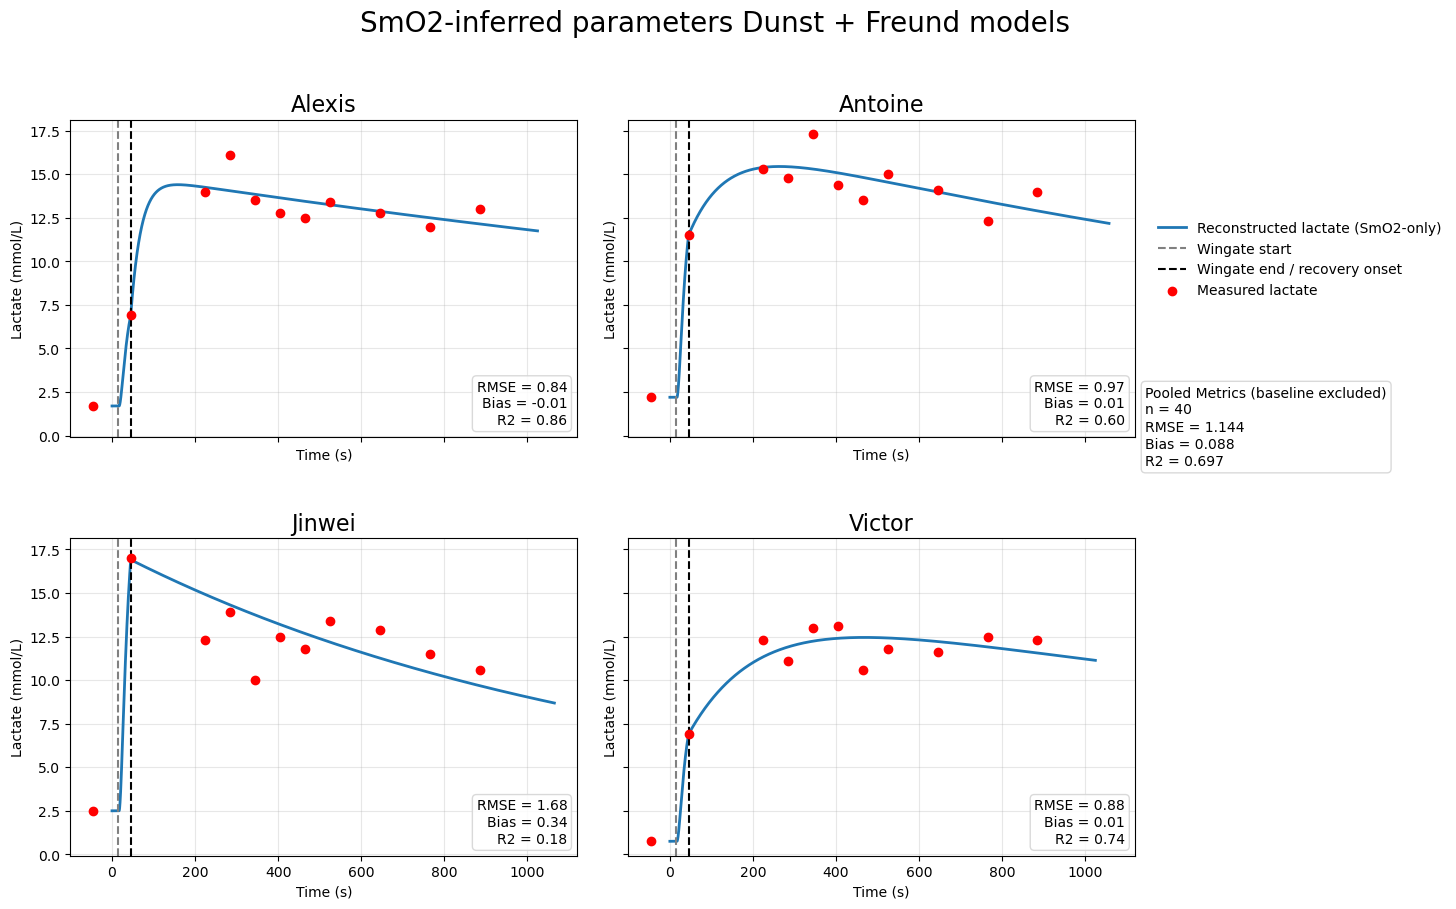

In [61]:
# Updated multi-panel plot: panel metrics moved from title to bottom-right box
n_subjects = len(model3_df)
ncols = 2
nrows = int(np.ceil(n_subjects / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.6 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

pooled_true = []
pooled_pred = []

for ax, (_, row) in zip(axes, model3_df.iterrows()):
    sid = row["id"]
    pred_curve = curve_store[sid].copy()
    t_pred = pred_curve["Time"].to_numpy(float)
    y_pred_curve = pred_curve["La_est"].to_numpy(float)

    ax.plot(pred_curve["Time"], pred_curve["La_est"], label="Reconstructed lactate (SmO2-only)", linewidth=2)
    ax.axvline(START_TIME_S, linestyle="--", label="Wingate start", color="gray")
    ax.axvline(END_TIME_S, linestyle="--", color="black", label="Wingate end / recovery onset")

    lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()
    panel_true = []
    panel_pred = []
    if not lac_sub.empty:
        abs_times = []
        la_vals = []
        time_rel = []

        for _, rr in lac_sub.iterrows():
            t_rel_min = rr["Time"]
            la_val = rr["[La]"]

            if pd.isna(t_rel_min) or pd.isna(la_val):
                continue

            if t_rel_min == -1:
                t_abs = START_TIME_S - 60
            else:
                t_abs = END_TIME_S + t_rel_min * 60

            abs_times.append(t_abs)
            la_vals.append(la_val)
            time_rel.append(t_rel_min)

        ax.scatter(abs_times, la_vals, color="red", label="Measured lactate", zorder=3)

        if len(abs_times) > 0:
            panel_pred = np.interp(np.asarray(abs_times, dtype=float), t_pred, y_pred_curve)
            panel_true = np.asarray(la_vals, dtype=float)

            time_rel_arr = np.asarray(time_rel, dtype=float)
            valid_mask = time_rel_arr != -1
            panel_true = panel_true[valid_mask]
            panel_pred = panel_pred[valid_mask]

            if len(panel_true) > 0:
                pooled_true.extend(panel_true.tolist())
                pooled_pred.extend(panel_pred.tolist())

    if len(panel_true) > 0:
        rmse_panel = float(np.sqrt(np.mean((panel_pred - panel_true) ** 2)))
        bias_panel = float(np.mean(panel_pred - panel_true))
        ss_res = float(np.sum((panel_true - panel_pred) ** 2))
        ss_tot = float(np.sum((panel_true - np.mean(panel_true)) ** 2))
        r2_panel = np.nan if np.isclose(ss_tot, 0.0) else float(1 - ss_res / ss_tot)
        r2_str = f"{r2_panel:.2f}" if np.isfinite(r2_panel) else "nan"
        panel_metrics = (
            f"RMSE = {rmse_panel:.2f}\n"
            f"Bias = {bias_panel:.2f}\n"
            f"R2 = {r2_str}"
        )
    else:
        panel_metrics = "RMSE = nan\nBias = nan\nR2 = nan"

    ax.set_title(f"{sid}", fontsize=16)
    ax.text(
        0.98,
        0.03,
        panel_metrics,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        linespacing=1.25,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "lightgray"},
    )
    ax.grid(True, alpha=0.3)

for i in range(n_subjects, len(axes)):
    axes[i].axis("off")

for ax in axes[:n_subjects]:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Lactate (mmol/L)")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax_idx = min(n_subjects - 1, ncols - 1)
legend_x = 1.02
if handles:
    axes[legend_ax_idx].legend(handles, labels, loc="center left", bbox_to_anchor=(legend_x, 0.56), frameon=False)

pooled_n = len(pooled_true)
if pooled_n > 0:
    pooled_true = np.asarray(pooled_true, dtype=float)
    pooled_pred = np.asarray(pooled_pred, dtype=float)
    pooled_rmse = float(np.sqrt(np.mean((pooled_pred - pooled_true) ** 2)))
    pooled_bias = float(np.mean(pooled_pred - pooled_true))
    pooled_ss_res = float(np.sum((pooled_true - pooled_pred) ** 2))
    pooled_ss_tot = float(np.sum((pooled_true - np.mean(pooled_true)) ** 2))
    pooled_r2 = np.nan if np.isclose(pooled_ss_tot, 0.0) else float(1 - pooled_ss_res / pooled_ss_tot)
    pooled_r2_str = f"{pooled_r2:.3f}" if np.isfinite(pooled_r2) else "nan"
    pooled_text = (
        f"Pooled Metrics (baseline excluded)\n"
        f"n = {pooled_n}\n"
        f"RMSE = {pooled_rmse:.3f}\n"
        f"Bias = {pooled_bias:.3f}\n"
        f"R2 = {pooled_r2_str}"
    )
else:
    pooled_text = "Pooled (baseline excluded): no valid points"

axes[legend_ax_idx].text(
    legend_x,
    -0.10,
    pooled_text,
    transform=axes[legend_ax_idx].transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    linespacing=1.3,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "lightgray"},
)

fig.suptitle("SmO2-inferred parameters Dunst + Freund models", y=1.02, fontsize=20)
fig.subplots_adjust(left=0.07, right=0.78, top=0.90, bottom=0.10, wspace=0.10, hspace=0.32)
plt.show()